<a href="https://colab.research.google.com/github/snaedis17/ERplus_BRCA2_TCGA_analysis/blob/main/tcga_brca2_pathway_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# we will use decoupler https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_psbk.html

!pip install decoupler


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.8/121.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 91.3 MB/s eta 0:00:00
  Created wheel for docrep: filename=docrep-0.3.2-py3-none-any.whl size=19876 sha256=52cb74e899a8f6be7cc7b5ab4248cf99b31eed4a95c6701180b2d23cf0bc560d
  Stored in directory: /root/.cache/pip/wheels/d6/19/ee/0a6a1793d91c449563b49ccab57ce52da3e6fab7614836bd8c
Successfully built docrep


In [2]:
# import needed packages
import numpy as np
import pandas as pd
import decoupler as dc

In [5]:
# To upload files in google collab, go to the left  folder (files) and upload it there.
# Load Deseq2 results.
results_df = pd.read_csv("/27des_BRCA2_NOAGE_PROTEINCODING.csv", index_col=0) # you can change index_col= as an argument
results_df

# important that the gene names are in the index.

,ENSEMBL,baseMean,log2FoldChange,lfcSE,pvalue,padj,GENEBIOTYPE
SYMBOL,,,,,,,
TSPAN6,ENSG00000000003,2892.083231,-0.084383,0.146615,0.107140,0.483146,protein_coding
TNMD,ENSG00000000005,121.293437,0.083613,0.159775,NaN,1.000000,protein_coding
DPM1,ENSG00000000419,2209.608144,0.134272,0.125794,0.085603,0.448284,protein_coding
SCYL3,ENSG00000000457,1677.780766,0.013150,0.090504,0.828511,0.947292,protein_coding
C1orf112,ENSG00000000460,623.718244,0.067581,0.115710,0.284591,0.677128,protein_coding
...,...,...,...,...,...,...,...
RP13-210D15.9,ENSG00000283644,1.242772,-0.001468,0.119769,0.989284,1.000000,protein_coding
RP11-244E17.1,ENSG00000283654,1.150833,1.191951,0.585469,NaN,1.000000,protein_coding
CTB-60B18.23,ENSG00000283663,0.003943,-0.000149,0.121344,0.991314,1.000000,protein_coding


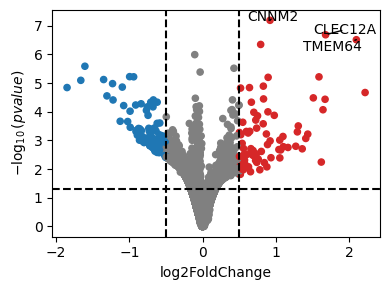

In [8]:
# we can do a volcano plot
dc.pl.volcano(results_df, top=3, x="log2FoldChange", y="pvalue") # change top argument to see top DEGs (based on p.adj)
# we can change x or y (p_adj) from our results_df.columns.

In [10]:
# generate the vector that we want to enrich
data = results_df[["log2FoldChange"]].T.rename(index={"log2FoldChange": "disease_vs_normal"})
data
# this can be each observation of our adata object (each patient in bulk data for example)


# After performing DEA, we can use the resulting gene-level statistics for enrichment analysis. While any statistic can be used,
# we recommend using t-values rather than log2FCs, as t-values account for the significance of the change.

SYMBOL,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,CTD-2537I9.19,RP5-994D16.12,RP11-192I24.1,RP11-402P6.15,EXOC3L2,RP13-210D15.9,RP11-244E17.1,CTB-60B18.23,RP3-454G6.2,RP5-937E21.8
disease_vs_normal,-0.084383,0.083613,0.134272,0.01315,0.067581,-0.017976,0.083569,-0.092006,-0.016996,0.094956,...,-0.005831,0.001081,-0.001397,-0.009714,-0.013083,-0.001468,1.191951,-0.000149,-0.07042,0.021852


In [11]:
#Enrichment analysis tests whether a specific set of omics features is “overrepresented” or “coordinated” in the measured data compared to a background distribution.
# We use ULM (Univariate Linear Model) as demonstrated here: https://doi.org/10.1093/bioadv/vbac016 it outperforms methods as GSEA.

#These sets are predefined based on existing biological knowledge and may vary depending on the omics technology used.
collectri = dc.op.collectri(organism="human") # TFs
progeny = dc.op.progeny(organism="human") # signalling pathways
hallmark = dc.op.hallmark(organism="human") # hallmarks

# for more information see the vignette: https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_psbk.html a brief description for each set of genes is included there.

In [18]:
lfc = results_df["log2FoldChange"].replace([np.inf, -np.inf], np.nan)
lfc = lfc.dropna()

data = lfc.to_frame().T
data.index = ["BRCA2_vs_WT"]


def enrich(df, net, thr):
  # Run
  tf_acts, tf_padj = dc.mt.ulm(data=df, net=net)
  # Filter by sign padj
  msk = (tf_padj.T < thr).iloc[:, 0]
  tf_acts = tf_acts.loc[:, msk]
  return tf_acts, tf_padj

# we use thr of 0.05 p.adj
thr = 0.05

tf_acts, tf_padj = enrich(data, collectri, thr)
pw_acts, pw_padj = enrich(data, progeny, thr)
hm_acts, hm_padj = enrich(data, hallmark, thr)

In [ ]:
# act -- enrichment score: sign reflects overrepresented (positive) or underrepresented (negative) compared to the background.
# padj -- adjusted p value.

#The scores should be interpreted such that larger magnitudes indicate greater significance

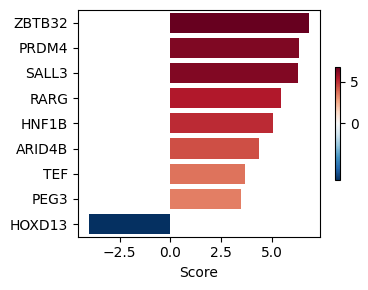

In [20]:
# we can plot our activity results, changing tf_acts or pw_acts or hm_acts
dc.pl.barplot(data=tf_acts, name="BRCA2_vs_WT", top=10, figsize=(4,3)) # changing top argument, we can show more or less.
# Blue bars mean underrepresented sets
# Red bars mean overrepresented sets

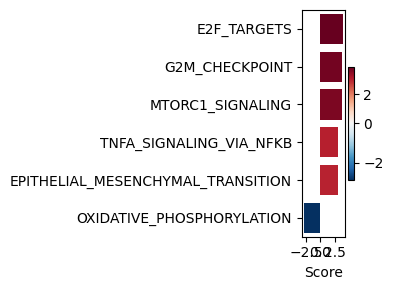

In [21]:
# you can change the input
dc.pl.barplot(data=hm_acts, name="BRCA2_vs_WT", top=20, figsize=(4, 3)) # changing top argument, we can show more or less.


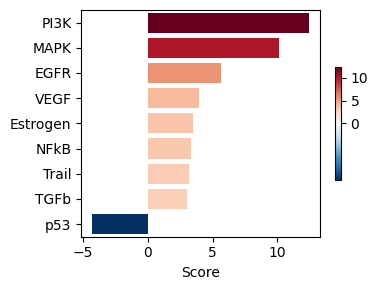

In [22]:
dc.pl.barplot(data=pw_acts, name="BRCA2_vs_WT", top=20, figsize=(4, 3)) # changing top argument, we can show more or less.


Plotting NFkB
Plotting EGFR
Plotting PI3K
Plotting MAPK


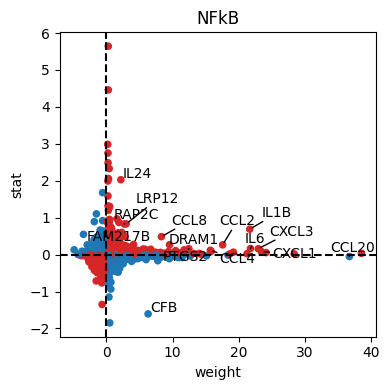

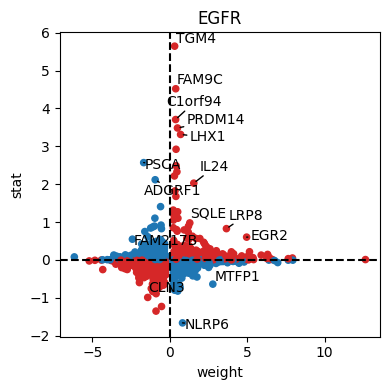

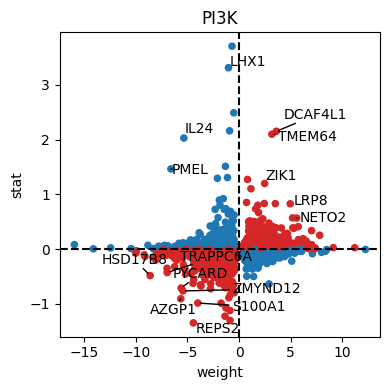

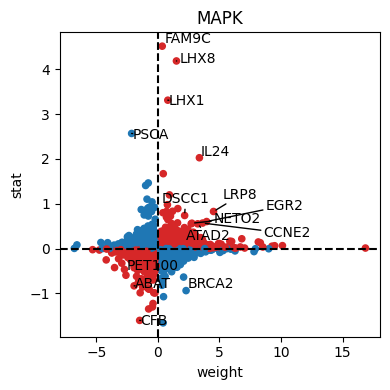

In [68]:
# progeny pathways have weights, we can see from our data the target genes that are enriched.
# change the "name" to the pathway that you want to show, in this case "NFkB" as could be the top upregulated.
# 1) halda bara tölfræðinni úr DE niðurstöðunum
plot_df = (
    results_df[["log2FoldChange"]]
    .rename(columns={"log2FoldChange": "stat"})
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

for pw in ["NFkB", "EGFR", "PI3K", "MAPK"]:
    print(f"Plotting {pw}")

    dc.pl.source_targets(
        data=plot_df,
        x="weight",
        y="stat",
        net=progeny,
        name=pw,
        top=15,
        figsize=(4,4)
    )

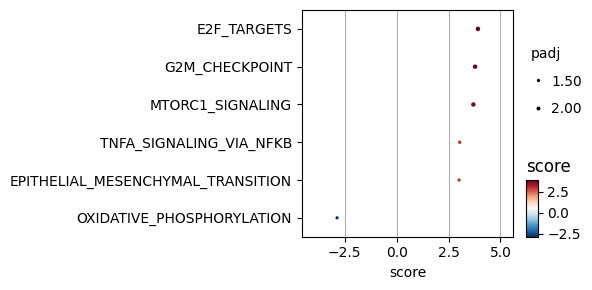

In [23]:
#  We can also do more fancy plots.
df = hm_acts.melt(value_name="score").merge(    # change hm_acts and hm_padj to the pathway that you want to plot.
    hm_padj.melt(value_name="pvalue")
    .assign(padj=lambda x: x["pvalue"].clip(2.22e-16, 1))
    .assign(padj=lambda x: np.log10(x["pvalue"]))
)
dc.pl.dotplot(df=df, x="score", y="variable", s="padj", c="score", top=20, vcenter=0, cmap='RdBu_r', figsize=(6, 3))

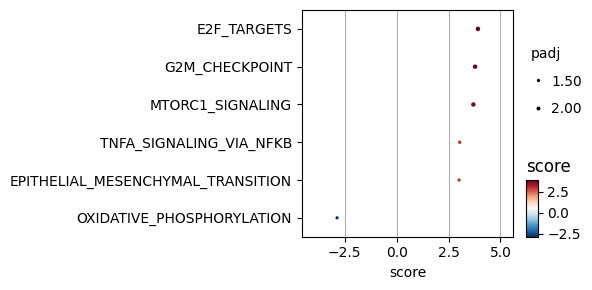

In [61]:
df = hm_acts.melt(value_name="score").merge(
    hm_padj.melt(value_name="pvalue")
    .assign(padj=lambda x: x["pvalue"].clip(2.22e-16, 1))
    .assign(padj=lambda x: -np.log10(x["pvalue"]))
)

dc.pl.dotplot(
    df=df,
    x="score",
    y="variable",
    s="padj",
    c="score",
    top=20,
    vcenter=0,
    cmap="RdBu_r",
    figsize=(6,3)
)

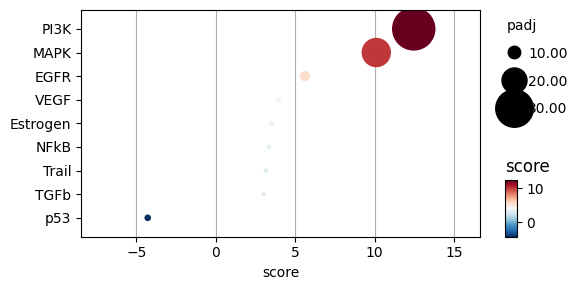

In [64]:
# @title Default title text
df = pw_acts.melt(value_name="score").merge(
    pw_padj.melt(value_name="pvalue")
    .assign(padj=lambda x: x["pvalue"].clip(2.22e-16, 1))
    .assign(padj=lambda x: -np.log10(x["pvalue"]))
)

dc.pl.dotplot(
    df=df,
    x="score",
    y="variable",
    s="padj",
    c="score",
    vcenter=0,
    cmap="RdBu_r",
    figsize=(6,3)
)
#Just the same as the barplot shows above


In [70]:
# choose pathway
pathway = "PI3K"

top_genes = (
    progeny[progeny.source == pathway]
    .sort_values("weight", ascending=False)
    .head(20)
)

top_genes

,source,target,weight,padj
37910,PI3K,C5orf52,12.239809,5.486389e-22
41642,PI3K,PTX3,11.207519,2.703431e-03
39235,PI3K,PSAT1,9.130983,3.232875e-06
38445,PI3K,TUBB2A,8.489069,1.866914e-09
39142,PI3K,F3,8.370580,1.876869e-06
38247,PI3K,TIGAR,7.985892,3.304904e-11
38031,PI3K,GCLM,7.815656,4.580429e-15
39152,PI3K,MTHFD2,7.376769,1.989503e-06
39782,PI3K,SLC7A11,7.358203,3.325256e-05
41809,PI3K,BNIP3,7.300947,3.436182e-03


In [71]:
genes = list(set(top_genes.target) & set(results_df.index))
genes[:10]

['PSAT1',
 'MAP1B',
 'AURKB',
 'CTPS1',
 'F3',
 'TIGAR',
 'PTX3',
 'TUBB2A',
 'TRIM16',
 'CHAC2']

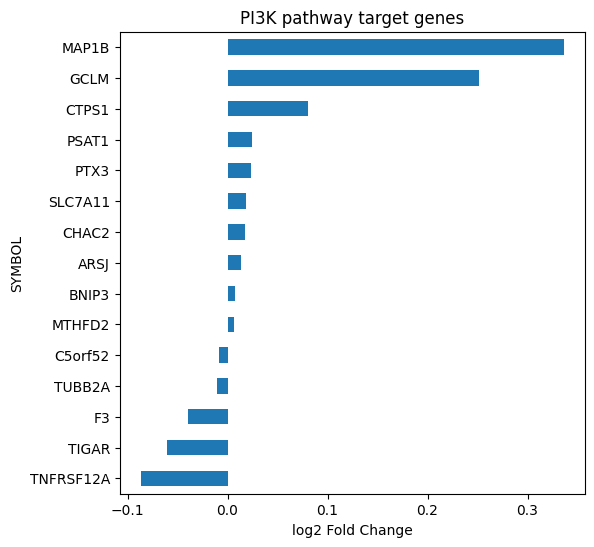

In [77]:
plot_data = results_df.loc[genes].sort_values("log2FoldChange")

plot_data["log2FoldChange"].plot.barh(figsize=(6,6))
plt.xlabel("log2 Fold Change")
plt.title("PI3K pathway target genes")
plt.show()

/tmp/ipykernel_564/761812796.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


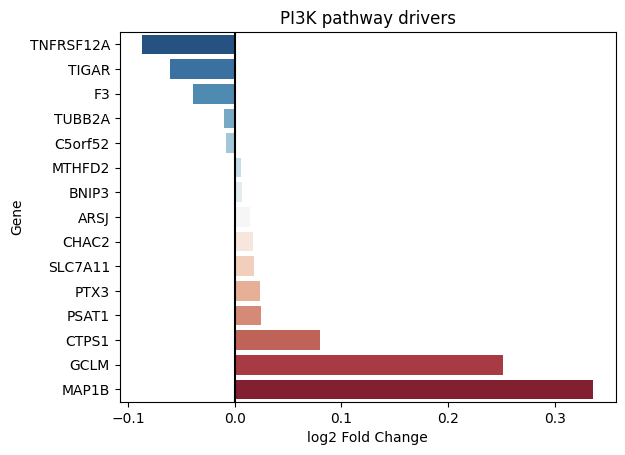

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_data = results_df.loc[genes].sort_values("log2FoldChange")

sns.barplot(
    x="log2FoldChange",
    y=plot_data.index,
    data=plot_data,
    palette="RdBu_r"
)

plt.axvline(0, color="black")
plt.title("PI3K pathway drivers")
plt.xlabel("log2 Fold Change")
plt.ylabel("Gene")
plt.show()

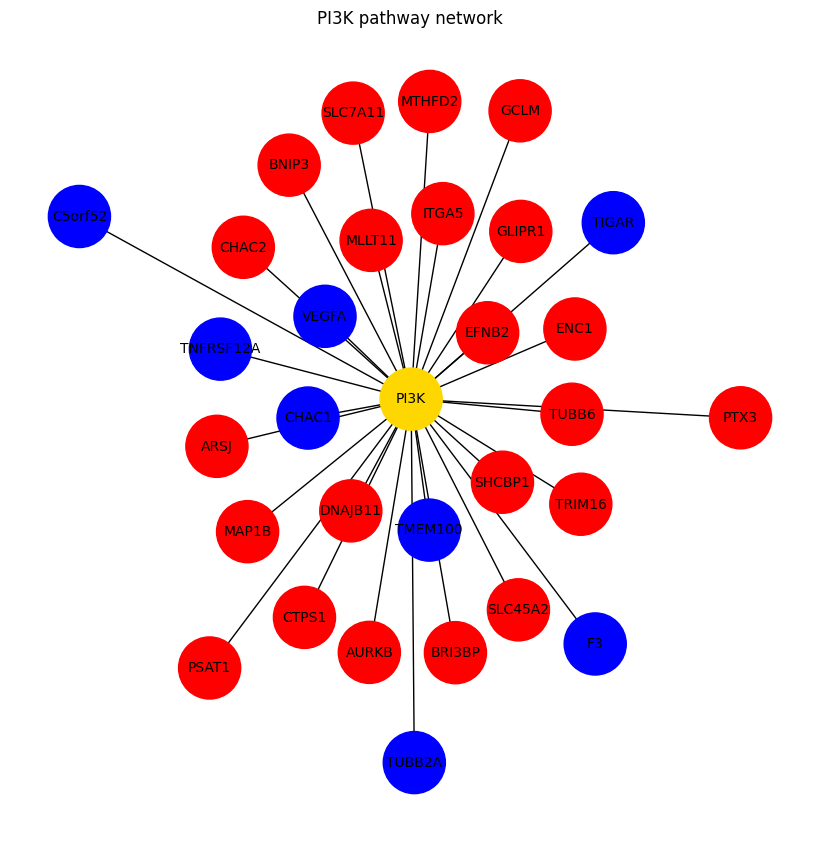

In [88]:
pathway = "PI3K"

net = progeny[progeny.source == pathway]

net = net.merge(
    results_df[["log2FoldChange"]],
    left_on="target",
    right_index=True
)

net = net.sort_values("weight", ascending=False).head(30)

import networkx as nx
import matplotlib.pyplot as plt

G = nx.from_pandas_edgelist(
    net,
    source="source",
    target="target",
    edge_attr="weight"
)

pos = nx.kamada_kawai_layout(G)

colors = []
for n in G.nodes:

    if n == pathway:
        colors.append("gold")
    else:
        fc = net.set_index("target").loc[n]["log2FoldChange"]
        colors.append("red" if fc > 0 else "blue")

plt.figure(figsize=(8,8))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color=colors,
    font_size=10
)

plt.title("PI3K pathway network")
plt.show()